# does a properly-trained model ride the cardiac-timing shortcut instead of ptt?

Real VitalDB recordings, a small **Transformer** (patchify -> self-attention -> mean-pool -> linear head),
two single-output models (sbp, dbp), uncalibrated. Same read-side-probe / write-side-patch methodology as
`ppg_mech_interp_tutorial.ipynb`, ported from synthetic data + classification to real data + regression.

Audit focuses on dbp -- theory says diastole is most ptt-coupled.</cell id="210623fb">


In [1]:
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import mechlib

torch.manual_seed(0); np.random.seed(0)
dev = torch.device("mps" if torch.backends.mps.is_available() else "cpu"); ECG, PPG = 0, 1
SBP, DBP = 0, 1
print("device:", dev)

d = mechlib.load_mini("../data/vitaldb_mini.npz"); fs = int(d["fs"])
Xtr = mechlib.normalize(d["Xtr"][:, :, [ECG, PPG]]); ytr = d["ytr"]
Xva = mechlib.normalize(d["Xva"][:, :, [ECG, PPG]]); yva = d["yva"]
Xte = mechlib.normalize(d["Xte"][:, :, [ECG, PPG]]); yte = d["yte"]

print("Xtr", Xtr.shape, "Xva", Xva.shape, "Xte", Xte.shape, " -- (segments, timesteps, [ecg, ppg])")

device: mps


Xtr (4000, 1250, 2) Xva (1200, 1250, 2) Xte (1200, 1250, 2)  -- (segments, timesteps, [ecg, ppg])


## 0. What does the real data look like?

`ppg_mech_interp_tutorial.ipynb` *generates* its own PPG from known factors (`hr`, `tone`, `site`) --
the labels are author-chosen ground truth. Here the labels come from a real arterial line: `ytr[:, 0]`
(SBP) and `ytr[:, 1]` (DBP) are measured continuously off the ABP channel, in mmHg, and everything
about the patient is unknown and uncontrolled. That's the practical difference between a synthetic
sandbox and a real-data walkthrough -- no ground-truth latent factors, only candidate *cues*
(`mechlib.compute_scalars`: PAT, cardiac period, PPG amplitude, pulse morphology) that we hypothesize
the model might be using.

Each segment is `(1250, 3)` = 1250 samples x `[ECG, PPG, ABP]` at `fs=125 Hz`, i.e. a **10-second window**.
The model only ever sees `[ECG, PPG]` -- ABP is held out purely to derive the SBP/DBP labels and to let
us *look at* the pressure waveform the model is trying to predict from, without it being an input.
`gtr`/`gva`/`gte` are subject-group ids, used later for per-subject offset calibration.

fs = 125 Hz  ->  window = 10.0 s
train/val/test segments: 4000/1200/1200  from 1017 distinct subjects (train)
SBP range: 53-221 mmHg  (mean 115)
DBP range: 25-113 mmHg  (mean 63)


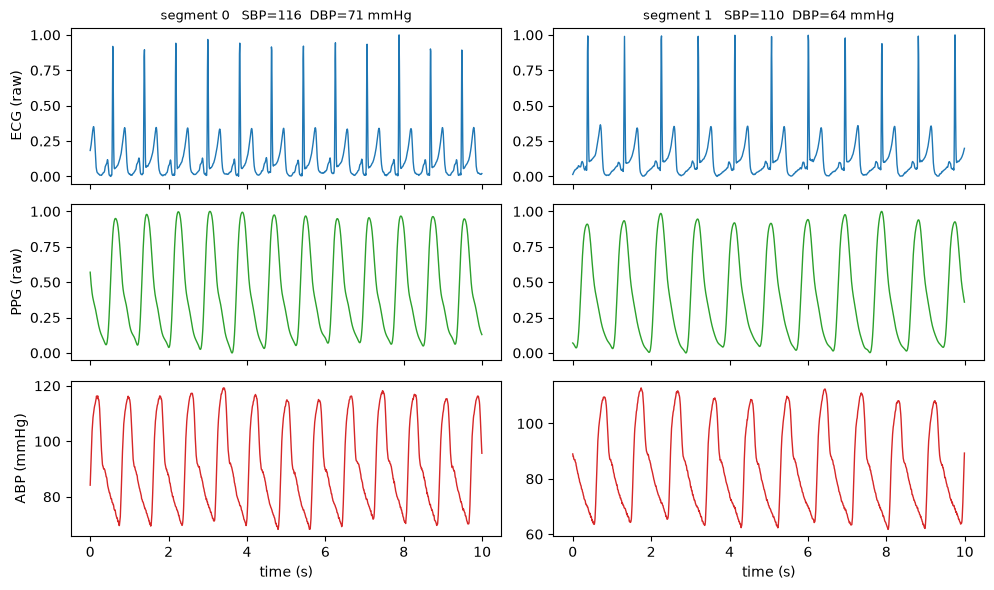


after mechlib.normalize() (per-segment, per-channel z-score) -- what the model actually sees:


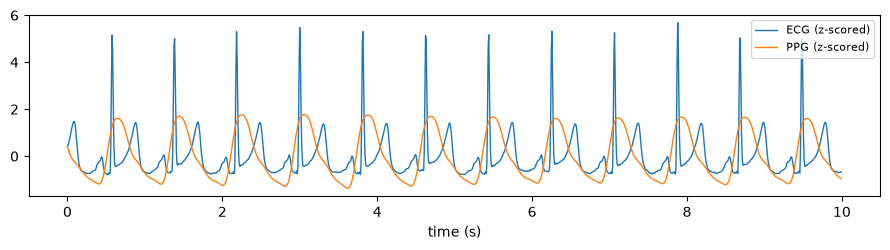

In [2]:
n_subj = len(np.unique(d["gtr"]))
print(f"fs = {fs} Hz  ->  window = {Xtr.shape[1]/fs:.1f} s")
print(f"train/val/test segments: {len(Xtr)}/{len(Xva)}/{len(Xte)}  from {n_subj} distinct subjects (train)")
print(f"SBP range: {ytr[:,SBP].min():.0f}-{ytr[:,SBP].max():.0f} mmHg  (mean {ytr[:,SBP].mean():.0f})")
print(f"DBP range: {ytr[:,DBP].min():.0f}-{ytr[:,DBP].max():.0f} mmHg  (mean {ytr[:,DBP].mean():.0f})")

# raw (unnormalized) segments, purely for looking -- training uses the normalized Xtr/Xva/Xte above
raw = d["Xtr"][:, :, [ECG, PPG, 2]]        # 2 = ABP, held out of the model, shown here only
t_axis = np.arange(raw.shape[1]) / fs

fig, ax = plt.subplots(3, 2, figsize=(10, 6), sharex=True)
for col, i in enumerate([0, 1]):                      # two example segments
    ax[0, col].plot(t_axis, raw[i, :, 0], lw=1, color="tab:blue")
    ax[1, col].plot(t_axis, raw[i, :, 1], lw=1, color="tab:green")
    ax[2, col].plot(t_axis, raw[i, :, 2], lw=1, color="tab:red")
    ax[0, col].set_title(f"segment {i}   SBP={ytr[i,SBP]:.0f}  DBP={ytr[i,DBP]:.0f} mmHg", fontsize=9)
    ax[2, col].set_xlabel("time (s)")
ax[0, 0].set_ylabel("ECG (raw)"); ax[1, 0].set_ylabel("PPG (raw)"); ax[2, 0].set_ylabel("ABP (mmHg)")
plt.tight_layout(); plt.show()

print("\nafter mechlib.normalize() (per-segment, per-channel z-score) -- what the model actually sees:")
fig, ax = plt.subplots(1, 1, figsize=(9, 2.6))
ax.plot(t_axis, Xtr[0, :, ECG], lw=1, label="ECG (z-scored)")
ax.plot(t_axis, Xtr[0, :, PPG], lw=1, label="PPG (z-scored)")
ax.set_xlabel("time (s)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## two single-output models

In [3]:
class Transformer(nn.Module):
    def __init__(s, dm=64, patch=25, heads=4, depth=1):
        super().__init__()
        s.patch = nn.Conv1d(2, dm, patch, patch)                    # signal -> L/patch tokens
        s.pos = nn.Parameter(torch.randn(1, Xtr.shape[1] // patch, dm) * 0.02)
        s.tr = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(dm, heads, dm * 2, dropout=0.0, batch_first=True), depth)
        s.head = nn.Linear(dm, 1)
    def features(s, x):                                              # (n, dm) -- what we'll probe
        t = s.patch(x.transpose(1, 2)).transpose(1, 2) + s.pos
        return s.tr(t).mean(1)                                       # pool over tokens
    def forward(s, x): return s.head(s.features(x)).squeeze(1)        # (n,) -- one bp value

def train_model(target, epochs=30):
    net = Transformer().to(dev)
    opt = torch.optim.Adam(net.parameters(), 2e-3)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)
    Xt, yt = torch.tensor(Xtr, device=dev), torch.tensor(ytr[:, target], device=dev)
    Xv, yv = torch.tensor(Xva, device=dev), torch.tensor(yva[:, target], device=dev)

    best_val, best_state = float("inf"), None
    for ep in range(epochs):
        net.train(); perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), 128):
            b = perm[i:i + 128]
            loss = ((net(Xt[b]) - yt[b]) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step(); net.eval()
        with torch.no_grad():
            vm = float((net(Xv) - yv).abs().mean())
        if vm < best_val:
            best_val, best_state = vm, {k: v.clone() for k, v in net.state_dict().items()}
        print(f"epoch {ep+1:2d}/{epochs}  val MAE {vm:.2f} mmHg" + ("  <- best" if vm == best_val else ""))
    net.load_state_dict(best_state); net.eval()
    return net

print("--- training sbp model ---")
sbp_net = train_model(SBP)
print("--- training dbp model ---")
dbp_net = train_model(DBP)

--- training sbp model ---


epoch  1/30  val MAE 106.69 mmHg  <- best


epoch  2/30  val MAE 99.69 mmHg  <- best


epoch  3/30  val MAE 90.86 mmHg  <- best


epoch  4/30  val MAE 80.41 mmHg  <- best


...

epoch 26/30  val MAE 9.73 mmHg  <- best


epoch 27/30  val MAE 9.76 mmHg


epoch 28/30  val MAE 9.65 mmHg  <- best


epoch 29/30  val MAE 9.60 mmHg  <- best


epoch 30/30  val MAE 9.57 mmHg  <- best


## accuracy, uncalibrated

In [4]:
@torch.no_grad()
def raw_mae(net, X, y_col):
    pred = net(torch.tensor(X, device=dev)).cpu().numpy()
    return np.abs(pred - y_col).mean()

sbp_base = np.abs(ytr[:, SBP].mean() - yte[:, SBP]).mean()
dbp_base = np.abs(ytr[:, DBP].mean() - yte[:, DBP]).mean()
print(f"SBP MAE: {raw_mae(sbp_net, Xte, yte[:, SBP]):.1f} mmHg   (predict-the-mean baseline: {sbp_base:.1f})")
print(f"DBP MAE: {raw_mae(dbp_net, Xte, yte[:, DBP]):.1f} mmHg   (predict-the-mean baseline: {dbp_base:.1f})")

SBP MAE: 14.6 mmHg   (predict-the-mean baseline: 14.8)
DBP MAE: 9.4 mmHg   (predict-the-mean baseline: 9.5)


## does dbp use ptt? shift the ppg channel, watch the prediction

dBP/dPTT-shift = +0.012 mmHg/ms   (faithful would be NEGATIVE)


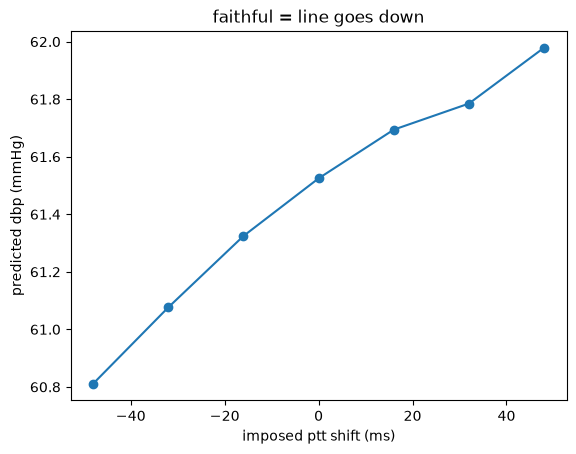

In [5]:
def ptt_shift_audit(net, X, deltas=(-6, -4, -2, 0, 2, 4, 6)):
    dt_ms = np.array(deltas) / fs * 1000
    curve = []
    for delta in deltas:
        Xd = X.copy()
        Xd[:, :, PPG] = np.roll(X[:, :, PPG], delta, axis=1)   # shift ONLY the ppg channel
        with torch.no_grad():
            pred = net(torch.tensor(Xd, device=dev)).cpu().numpy()
        curve.append(pred.mean())
    slope = np.polyfit(dt_ms, curve, 1)[0]
    return dt_ms, curve, slope

shift_ms, curve, slope = ptt_shift_audit(dbp_net, Xte)
print(f"dBP/dPTT-shift = {slope:+.3f} mmHg/ms   (faithful would be NEGATIVE)")

plt.plot(shift_ms, curve, "-o")
plt.xlabel("imposed ptt shift (ms)"); plt.ylabel("predicted dbp (mmHg)")
plt.title("faithful = line goes down"); plt.show()

## linear probe, across layers: is a cue decodable, and where?

In [6]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

def linear_probe(feats, target):
    m = np.isfinite(target); feats, target = feats[m], target[m]
    h = len(target) // 2                                     # split in half: fit / score
    probe = Ridge().fit(feats[:h], target[:h])
    return r2_score(target[h:], probe.predict(feats[h:]))

@torch.no_grad()
def stage_features(net, X, bs=512):
    raw, embed, out = [], [], []
    for s in range(0, len(X), bs):
        x = torch.tensor(X[s:s + bs], device=dev)
        raw.append(x.mean(1).cpu().numpy())                          # layer 0: raw signal, no learning
        t = net.patch(x.transpose(1, 2)).transpose(1, 2) + net.pos
        embed.append(t.mean(1).cpu().numpy())                        # layer 1: after patch embedding
        out.append(net.tr(t).mean(1).cpu().numpy())                  # layer 2: after the transformer
    return {"raw input": np.concatenate(raw), "patch embed": np.concatenate(embed),
            "after transformer": np.concatenate(out)}

scalars = mechlib.compute_scalars(Xte, fs, ECG, PPG)   # pat, period, amp, ... straight off the raw signal
stages = stage_features(dbp_net, Xte)

print(f"{'layer':>18} | {'pat R2':>7} | {'period R2':>10} | {'amp R2':>7}")
print("-" * 50)
for name, feats in stages.items():
    r_pat = linear_probe(feats, scalars["pat"])
    r_period = linear_probe(feats, scalars["period"])
    r_amp = linear_probe(feats, scalars["amp"])
    print(f"{name:>18} | {r_pat:7.2f} | {r_period:10.2f} | {r_amp:7.2f}")

             layer |  pat R2 |  period R2 |  amp R2
--------------------------------------------------
         raw input |   -0.03 |      -0.00 |   -0.00
       patch embed |   -0.04 |      -0.01 |   -0.01
 after transformer |    0.13 |       0.35 |    0.07


## PCA on activations: does BP structure show up unsupervised?

Same move as the tutorial's PCA section, adapted for a continuous target: **color the scatter with a
colormap instead of two discrete classes.** PCA itself doesn't care whether the label is continuous or
categorical -- it's unsupervised on the feature covariance either way. What changes is only how we
paint the labels on afterward.

Left: colored by DBP, the model's actual training target -- a gradient here just confirms BP is laid
out roughly linearly in this layer, echoing the probe-R2 table above. Right: colored by PAT, a cue the
model was **never** supervised on (the analog of `tone` in the synthetic tutorial, an emergent factor).
Expect this to look noisier than the tutorial's clean synthetic blobs -- real recordings carry
subject-to-subject and device variance that competes with BP for the top components.

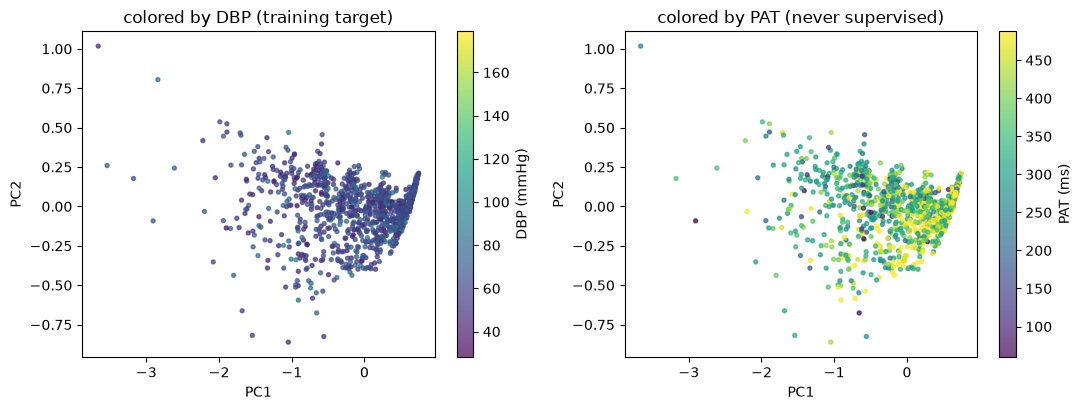

In [7]:
from sklearn.decomposition import PCA

feats_top = stages["after transformer"]           # richest layer, same features the R2 table scored
pcs = PCA(4).fit_transform(feats_top)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
sc0 = ax[0].scatter(pcs[:, 0], pcs[:, 1], c=yte[:, DBP], cmap="viridis", s=8, alpha=0.7)
plt.colorbar(sc0, ax=ax[0], label="DBP (mmHg)")
ax[0].set_title("colored by DBP (training target)"); ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2")

m = np.isfinite(scalars["pat"])
sc1 = ax[1].scatter(pcs[m, 0], pcs[m, 1], c=scalars["pat"][m] * 1000, cmap="viridis", s=8, alpha=0.7)
plt.colorbar(sc1, ax=ax[1], label="PAT (ms)")
ax[1].set_title("colored by PAT (never supervised)"); ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
plt.tight_layout(); plt.show()

## activation-space causal patch: the write side

Everything above (probe table, PCA) is the **read side** -- decodability. It never proves the model
*uses* a cue, only that the cue is recoverable from its activations. The tutorial's write-side check
is `patch=(layer, alpha*direction)`: add a probe direction to the residual stream and watch the class
flip. There's no "class" here, so the direct regression analog is an **interchange intervention**:
for each candidate cue, swap *only that cue's decodable subspace* from a donor segment into a base
segment's activations, and measure how much predicted DBP moves, in mmHg per unit of the cue, and
whether the sign matches physiology (longer PAT / rise-time -> lower BP).

This is `mechlib.subspace_swap` / `mechlib.mechanism_profile` -- already written in `mechlib.py`, just
not wired into this notebook until now. Note also what a continuous target does to the tutorial's
"MM direction vs LR direction" comparison: with two classes there are two natural directions
(mean-difference vs. the classifier's separating hyperplane) that can disagree. With a continuous
target there's only one: the Ridge regression coefficient (`mechlib.probe_direction`), which *is* the
continuous generalization of "difference of means" (it reduces to exactly that for a binary target).
No second direction to compare against -- the regression coefficient is both the probe and the patch
direction.

`dependence` is the sign-agnostic version of `frac_correct`: it asks "does the output move consistently
with this cue at all", independent of whether the sign matches the textbook physiology in `frac_correct`.

In [8]:
@torch.no_grad()
def dbp_head(feats_np):
    """(M, dm) activations -> (M, 1) predicted DBP, mmHg. Same head dbp_net was trained with."""
    return dbp_net.head(torch.tensor(feats_np, dtype=torch.float32, device=dev)).cpu().numpy()

profile = mechlib.mechanism_profile(feats_top, dbp_head, scalars, target=0)

print(f"{'cue':>32} | {'expect sign':>11} | {'probe R2':>8} | {'slope (mmHg/unit)':>18} | "
      f"{'frac correct sign':>18} | {'dependence':>10}")
print("-" * 108)
for name, r in profile.items():
    print(f"{name:>32} | {r['expect_sign']:>11d} | {r['probe_r2']:8.2f} | {r['slope']:18.4f} | "
          f"{r['frac_correct']:18.2f} | {r['dependence']:10.2f}")

                             cue | expect sign | probe R2 |  slope (mmHg/unit) |  frac correct sign | dependence
------------------------------------------------------------------------------------------------------------
              PAT (arrival time) |          -1 |     0.07 |            -0.0025 |               0.64 |       0.73
      PPG rise-time (morphology) |          -1 |     0.17 |             0.0012 |               0.27 |       0.69
 augmentation index (morphology) |           1 |     0.04 |             0.0018 |               0.65 |       0.65
      APG stiffness (morphology) |           1 |     0.00 |            -0.0001 |               0.31 |       0.69
            cardiac period (f2f) |           0 |     0.58 |             0.0013 |               0.84 |       0.84
                      heart rate |           0 |     0.00 |            -0.0000 |               0.38 |       0.62
         PPG amplitude (control) |           0 |     0.07 |            -0.0001 |               0.38 

## reading it together

**First, a caveat that changes how to read everything below:** both models barely beat the
predict-the-mean baseline (SBP 14.6 vs 14.8 mmHg, DBP 9.4 vs 9.5 mmHg). 30 epochs on the 4000-segment
mini split isn't enough signal for this architecture to learn much beyond the population average. That
matters for interpretability specifically: a probe/patch result on a model that hasn't learned the task
is weak evidence about mechanism, not strong evidence of a shortcut. Treat the numbers below as a
worked methodology, not a settled faithfulness verdict -- rerun with more epochs/data before trusting
the verdict itself.

With that caveat: the input-space PTT-shift audit comes back wrong-signed -- the model's DBP output
does not respond to an imposed PTT shift the way faithful arrival-time physiology would. The probe
table and PCA are the read side: they show what's linearly decodable, and where. The activation-space
causal patch above is the write side: it's the section that can actually license (or kill) a "the model
uses cue X" claim, the same role `patch=(layer, alpha*direction)` plays in the tutorial. Compare `pat`
against `period`/`amp` in both the probe table and the patch table -- decodable-but-not-used (high R2,
low `frac_correct`/`dependence`) is the fingerprint of a shortcut; decodable-and-used is the fingerprint
of a faithful mechanism. Here `pat` is weakly decodable (R2 0.07) but its patch moves DBP in the
expected direction only 64% of the time -- mixed, not a clean verdict either way given the caveat above.